### Doing the similar thing as in Std mh mcmc, for getting the theoretical vs observed values

In [6]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

h = 0.71           
H0 = 100 * h          # in km/s/Mpc
c = 299792.458        # in km/s
Omega_m = 0.3         # Note: Omega_m + Omega_Lambda = 1.0, which means the universe is "flat"
Omega_Lambda = 0.7    # and Omega_r is approximately 0

def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def integrand(z):
    return c / H(z)

def comoving_distance(z):
    integral, error = integrate.quad(integrand, 0, z)
    return integral

def angular_diameter_distance(z):
    D_c = comoving_distance(z)
    return D_c / (1 + z)

def luminosity_distance(z):
    D_c = comoving_distance(z)
    return D_c * (1 + z)

def physical_distance(z):
    return comoving_distance(z) / (1 + z)

In [ ]:
z_values_1 = np.linspace(0.01, 0.1, 200)
z_values_2 = np.linspace(0.1, 1, 200)
z_values_3 = np.linspace(1, 10, 200)
z_values = np.concatenate((z_values_1, z_values_2, z_values_3))
 
D_c_values = np.array([comoving_distance(z) for z in z_values])
 
D_A_values = D_c_values / (1 + z_values)  
D_L_values = D_c_values * (1 + z_values)

mu_values = 5 * np.log10(D_L_values) + 25

data = pd.read_csv("Pantheon_SNdata.csv") # To check the data, you can use: print(data.head())

TypeError: integrand() missing 3 required positional arguments: 'H0', 'omega_m', and 'w'

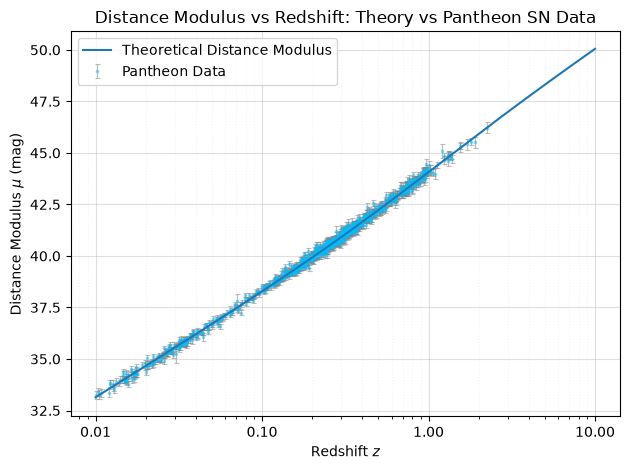

In [13]:
plt.plot(z_values, mu_values, label='Theoretical Distance Modulus', zorder=2)
 
plt.errorbar(
    data['zcmb'], data['dist_mod'], yerr=data['dmb'],
    fmt='o', mfc='deepskyblue', mec='none', ms=2.5,
    ecolor='gray', alpha=0.5,
    capsize=1.8, capthick=0.8, elinewidth=0.9,
    label='Pantheon Data', zorder=1
)
 
plt.xscale('log')
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
 
plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance Modulus $\mu$ (mag)')
plt.title('Distance Modulus vs Redshift: Theory vs Pantheon SN Data')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15, linestyle=':')
 
plt.tight_layout()
plt.show()

---


In [ ]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

In [ ]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD'):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)
 
    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)
 
    fig, ax = plt.subplots(figsize=(6, 4))
 
    # density=True normalizes the histogram so its area = 1, matching the
    # Gaussian pdf's area — otherwise the curve and bars are on different scales
    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')
 
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')
 
    ax.axvline(mu, color='red', linestyle='--', lw=0.8)
 
    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()
 
    return mu, sigma

---

# Standard and Adaptive MH MCMC method to estimation of multiparametered model 

#### First, we'll do standard method to get the covariance matrix

we do it for smaller # of iterations, to avoid time comsuming computation

In [18]:
def Hubble(z, H0, omega_m, w):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + (1 - omega_m) * (1 + z)**(3 * (1 + w)))

def integrand(z, H0, omega_m, w):
    return c / Hubble(z, H0, omega_m, w)

def DISTANCE_MODULUS4(z, H0, omega_m, w):
    D_c, error = integrate.quad(integrand, 0, z, args=(H0, omega_m, w))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25

def CALCULATE_NEW_w(omega_m_prev, H0_prev, w_prev,
                    domega_m, dH0, dw,
                    omega_m_range, H0_range, w_range):
    omega_m_new = omega_m_prev + domega_m * np.random.normal(0, 1)
    H0_new = H0_prev + dH0 * np.random.normal(0, 1)
    w_new = w_prev + dw * np.random.normal(0, 1)
    if (omega_m_range[0] <= omega_m_new <= omega_m_range[1]
        and H0_range[0] <= H0_new <= H0_range[1]
        and w_range[0] <= w_new <= w_range[1]):
        return omega_m_new, H0_new, w_new
    return CALCULATE_NEW_w(omega_m_prev, H0_prev, w_prev, domega_m, dH0, dw,
                           omega_m_range, H0_range, w_range)

In [17]:

# define some constants (parameters)
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0}')

N_iterations =2000 

Ω_m range:[0.15, 0.45], ΔΩ_m:0.005,
H0 range:[55, 85], ΔH0:0.2


In [19]:
w_range = [-2.0, 0.0]
delta_w = 0.03
print(f'w range:{w_range}, \u0394w:{delta_w}')
 
mcmc_df = pd.DataFrame(columns=['H0', 'Omega_m', 'w', 'Chi_sq', 'Type'])
 
omega_m_prev = np.random.uniform(*omega_m_range)
H0_prev = np.random.uniform(*H0_range)
w_prev = np.random.uniform(*w_range)
print(f'Initial values: Omega_m={omega_m_prev:.3f}, H0={H0_prev:.2f}, w={w_prev:.3f}')
 
chi_sq1 = chi_sq(data['dist_mod'],
                 [DISTANCE_MODULUS4(z, H0_prev, omega_m_prev, w_prev) for z in data['zcmb']],
                 data['dmb'])
print("Chi_squared initial:", chi_sq1, '\n')
 
print("Begin MH-MCMC\n")
for nstep in range(N_iterations):
    omega_m_new, H0_new, w_new = CALCULATE_NEW_w(omega_m_prev, H0_prev, w_prev,
                                                 delta_omega_m, delta_H0, delta_w,
                                                 omega_m_range, H0_range, w_range)
    chi_sq2 = chi_sq(data['dist_mod'],
                     [DISTANCE_MODULUS4(z, H0_new, omega_m_new, w_new) for z in data['zcmb']],
                     data['dmb'])
 
    if chi_sq2 <= chi_sq1:
        omega_m_prev, H0_prev, w_prev, chi_sq1 = omega_m_new, H0_new, w_new, chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [H0_prev, omega_m_prev, w_prev, chi_sq1, type_val]
        print(f'{nstep}) -- type 1, omega_m: {omega_m_prev}, H0 = {H0_prev}, w = {w_prev}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0, 1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_prev, H0_prev, w_prev, chi_sq1 = omega_m_new, H0_new, w_new, chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [H0_prev, omega_m_prev, w_prev, chi_sq1, type_val]
            print(f'{nstep}) -- type 2, omega_m: {omega_m_prev}, H0 = {H0_prev}, w = {w_prev}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
 
print("\nomega_m_Final, H0_Final, w_Final:", omega_m_prev, H0_prev, w_prev)
print('Final Chi_sq value:', chi_sq1)

w range:[-2.0, 0.0], Δw:0.03
Initial values: Omega_m=0.361, H0=70.50, w=-0.882
Chi_squared initial: 1347.7634271968564 

Begin MH-MCMC

0) -- type 1, omega_m: 0.3594040645235212, H0 = 70.73706743475618, w = -0.9379844175822456, chi_sq: 1296.9313439484827
5) -- type 1, omega_m: 0.35669006556900906, H0 = 70.69710975235252, w = -0.9343847903459341, chi_sq: 1284.7821982322425
6) -- type 1, omega_m: 0.36213111682269566, H0 = 70.68393813458253, w = -0.9448055765036301, chi_sq: 1284.3083970743482
7) -- type 1, omega_m: 0.369235205995893, H0 = 70.51601262975444, w = -0.9871007432660782, chi_sq: 1214.5850705588073
8) -- type 1, omega_m: 0.3678960723213841, H0 = 70.23338569687964, w = -1.0068502972072024, chi_sq: 1145.4494743238035
11) -- type 1, omega_m: 0.3634589724488311, H0 = 70.39534047106295, w = -1.0375838004464963, chi_sq: 1124.772218645184
12) -- type 1, omega_m: 0.3636058618342764, H0 = 70.43496512453355, w = -1.1239603589019211, chi_sq: 1066.1291139448374
13) -- type 1, omega_m: 0.365

In [20]:
#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.05*final_chi_sq].index[0]

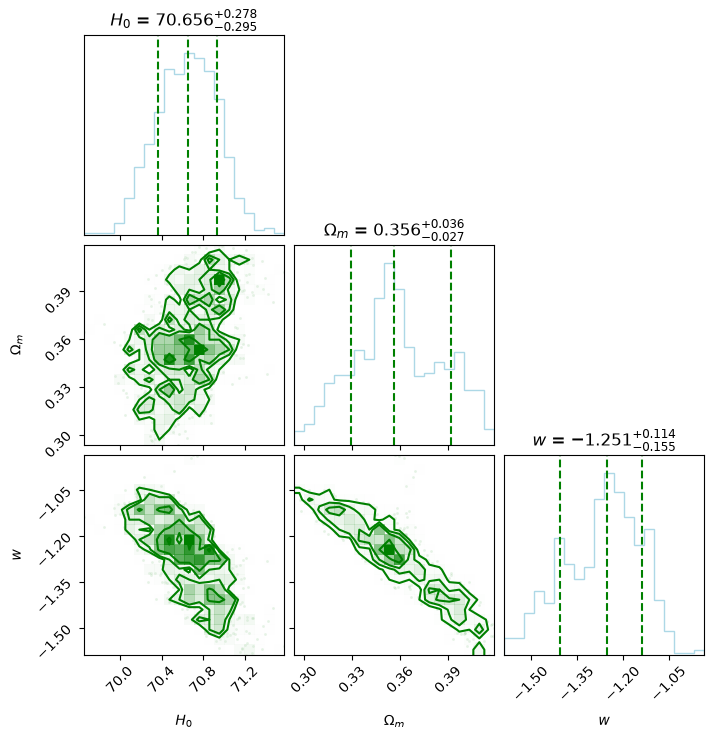

In [21]:
import corner

samples_w = mcmc_df[['H0', 'Omega_m', 'w']].to_numpy()
labels_w = ['$H_0$', '$\\Omega_m$', '$w$']

figure = corner.corner(samples_w, labels=labels_w, show_titles=True,
                       quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".3f", color='green', hist_kwargs={"color": "lightblue"})

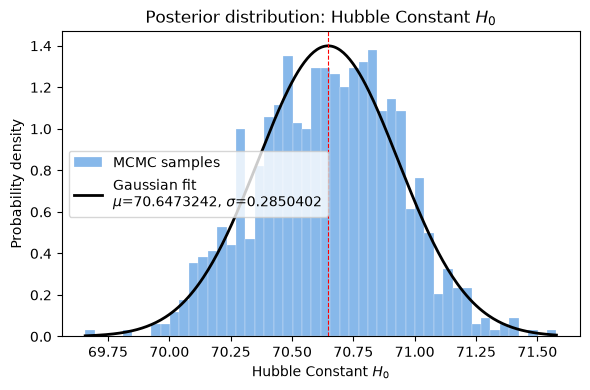

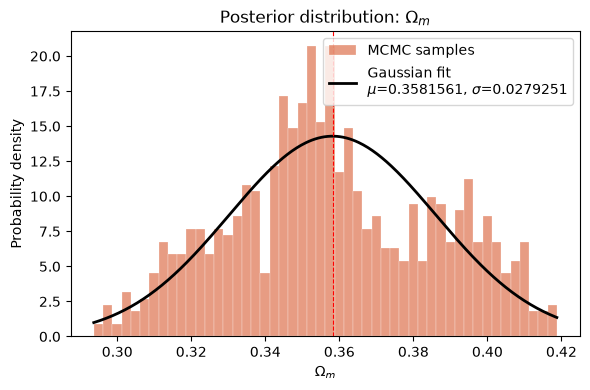

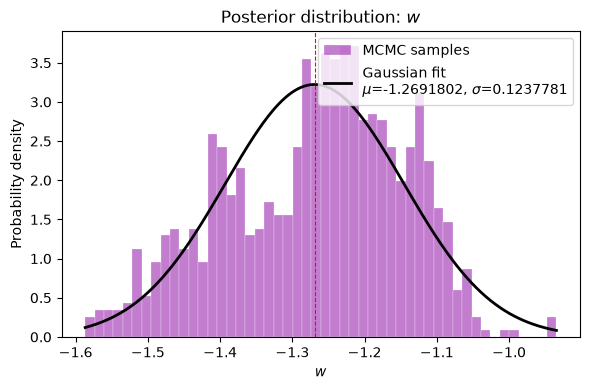

H0      = 70.65 +/- 0.29 km/s/Mpc
Omega_m = 0.358 +/- 0.028
w       = -1.269 +/- 0.124


In [22]:
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_df['H0'], 'Hubble Constant $H_0$',
                                          color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_df['Omega_m'], '$\\Omega_m$',
                                          color='#D85A30')
w_mean, w_std = plot_hist_with_gaussian(mcmc_df['w'], '$w$',
                                        color='#9C27B0')
 
print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"w       = {w_mean:.3f} +/- {w_std:.3f}")

# Adaptive MH MCMC for parameters H0, Omega_m and w

In [27]:
bounds = np.array([
    [55.0, 85.0],    # H0
    [0.15, 0.45],    # Omega_m
    [-2.0,  0.0],])  # w                   # bounds for the parameters

In [ ]:
def in_bounds(theta):
    return np.all((bounds[:, 0] <= theta) & (theta <= bounds[:, 1])) # this function checks if the parameters are within the specified bounds
                                                                     # where theta is the array of parameters [H0, Omega_m, w]
def chi2_at(theta):
    H0, omega_m, w = theta
    theo = [DISTANCE_MODULUS4(z, H0, omega_m, w) for z in data['zcmb']]
    return chi_sq(data['dist_mod'], theo, data['dmb']) #this function calculates the chi-squared value for a given set of parameters (H0, omega_m, w)

In [24]:
n_iter = 20000

prev = mcmc_df[['H0', 'Omega_m', 'w']].to_numpy()
cov = (2.38**2 / 3) * np.cov(prev.T)     # Roberts & Rosenthal optimal scaling = 2.38^2/d, where d is the number of parameters (3 in this case)
print("Proposal covariance from previous chain:\n", cov)

Proposal covariance from previous chain:
 [[ 0.15358007  0.00685694 -0.04605636]
 [ 0.00685694  0.00147405 -0.00588714]
 [-0.04605636 -0.00588714  0.02896078]]


In [28]:
# --- plain Metropolis with that FIXED covariance ---
theta = np.array([H0_mean, Om_mean, w_mean])  # starting point for the MCMC chain
chi2_curr = chi2_at(theta)

chain = np.empty((n_iter, 3))
chi2_chain = np.empty(n_iter)
n_accepted = 0

for n in range(n_iter):
    theta_new = np.random.multivariate_normal(theta, cov)   # cov never changes
    if in_bounds(theta_new):
        chi2_new = chi2_at(theta_new)
        if chi2_new <= chi2_curr or np.exp(-(chi2_new - chi2_curr)/2) > np.random.uniform():
            theta, chi2_curr = theta_new, chi2_new
            n_accepted += 1
    chain[n] = theta
    chi2_chain[n] = chi2_curr

print(f"Acceptance rate: {n_accepted/n_iter:.1%}")
mcmc_pc = pd.DataFrame(chain, columns=['H0', 'Omega_m', 'w'])
mcmc_pc['Chi_sq'] = chi2_chain

Acceptance rate: 25.6%


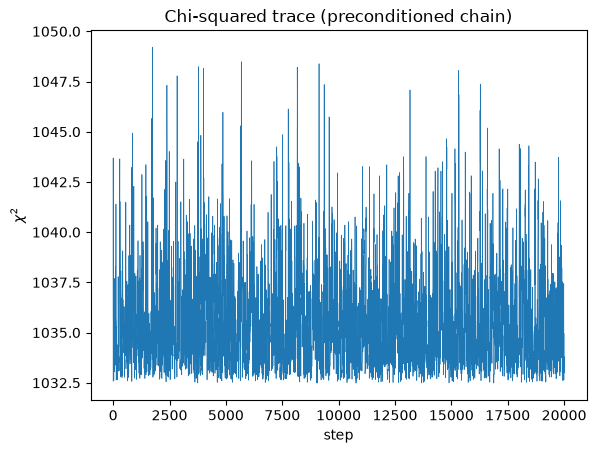

Discarded 5 burn-in rows, 882 remain


In [29]:
# --- diagnostic trace + burn-in cut ---
plt.plot(mcmc_pc['Chi_sq'].values, lw=0.5)
plt.xlabel('step')
plt.ylabel(r'$\chi^2$')
plt.title('Chi-squared trace (preconditioned chain)')
plt.show()

final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.1*final_chi_sq].index[0]
print(f"Discarded {first_valid_index} burn-in rows, {len(mcmc_df) - first_valid_index} remain")

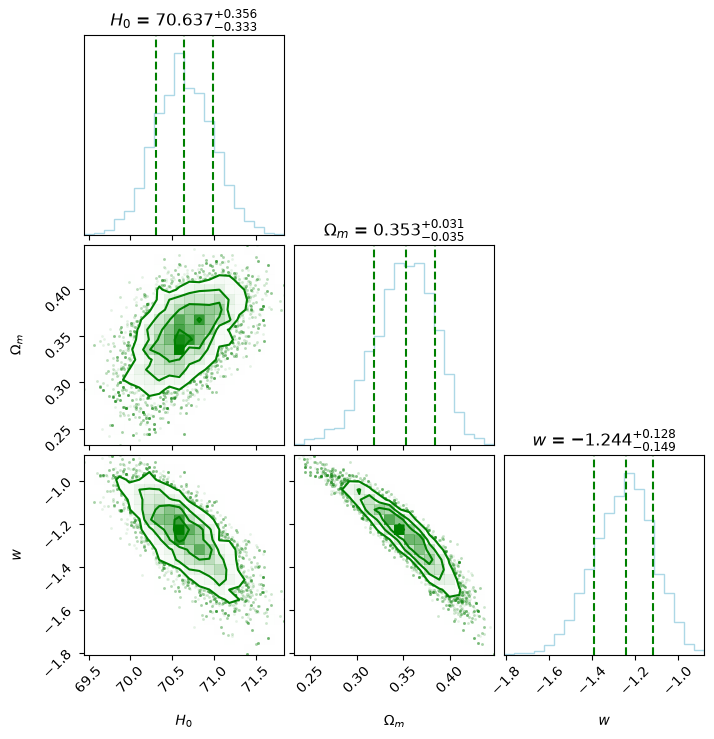

In [30]:

samples = mcmc_pc[['H0', 'Omega_m', 'w']].to_numpy()
labels = ['$H_0$', '$\\Omega_m$', '$w$']
figure = corner.corner(samples, labels=labels, show_titles=True,
                       quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".3f", color='green', hist_kwargs={"color": "lightblue"})

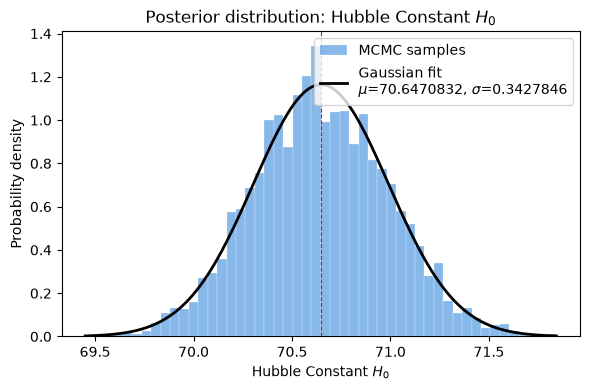

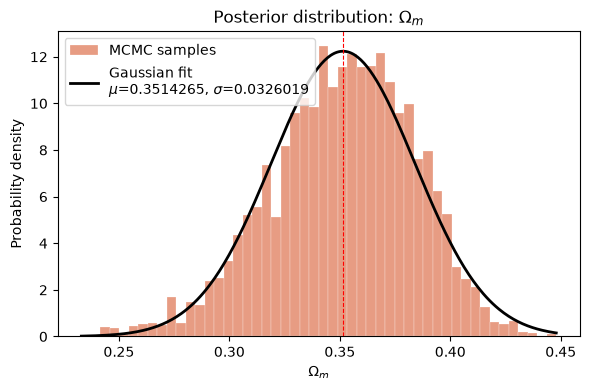

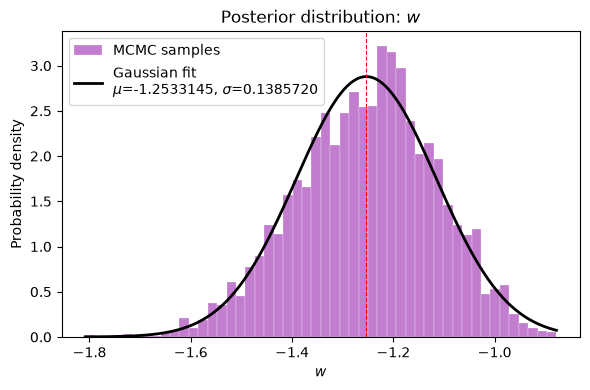

H0      = 70.65 +/- 0.34 km/s/Mpc
Omega_m = 0.351 +/- 0.033
w       = -1.253 +/- 0.139


In [31]:
# --- histograms + Gaussian fits ---
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_pc['H0'], 'Hubble Constant $H_0$',
                                          color='#378ADD')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_pc['Omega_m'], '$\\Omega_m$',
                                          color='#D85A30')
w_mean, w_std = plot_hist_with_gaussian(mcmc_pc['w'], '$w$',
                                        color='#9C27B0')

print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"w       = {w_mean:.3f} +/- {w_std:.3f}")